In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bank-full.csv to bank-full.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("bank-full.csv", sep=";")

# Display first rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Check dataset information
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Create conversion variable
df["converted"] = np.where(df["y"] == "yes", 1, 0)

# Convert contact channel into readable labels
df["contact_channel"] = df["contact"].replace({
    "cellular": "Cellular",
    "telephone": "Telephone",
    "unknown": "Unknown"
})

# Create campaign frequency groups
df["campaign_group"] = np.where(
    df["campaign"] == 1,
    "1 Contact",
    np.where(
        df["campaign"] <= 3,
        "2–3 Contacts",
        "4+ Contacts"
    )
)

df.head()

Dataset shape: (45211, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,converted,contact_channel,campaign_group
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,Unknown,1 Contact
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,Unknown,1 Contact
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,Unknown,1 Contact
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,Unknown,1 Contact
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,Unknown,1 Contact


In [ ]:
# Total prospects already contacted
total_prospects = len(df)

# Converted customers
total_customers = df["converted"].sum()

# Non-converted prospects
total_dropoff = total_prospects - total_customers

# Conversion rate
conversion_rate = (total_customers / total_prospects) * 100

# Drop-off rate
dropoff_rate = (total_dropoff / total_prospects) * 100

# Average tenure/engagement equivalent
average_duration = df["duration"].mean()

# Average number of contacts
average_campaign = df["campaign"].mean()

print("TOTAL PROSPECTS:", total_prospects)
print("CONVERTED CUSTOMERS:", total_customers)
print("DROP-OFF:", total_dropoff)
print("CONVERSION RATE:", round(conversion_rate, 2), "%")
print("DROP-OFF RATE:", round(dropoff_rate, 2), "%")
print("AVERAGE CALL DURATION:", round(average_duration, 2), "seconds")
print("AVERAGE CONTACTS:", round(average_campaign, 2))

TOTAL PROSPECTS: 45211
CONVERTED CUSTOMERS: 5289
DROP-OFF: 39922
CONVERSION RATE: 11.7 %
DROP-OFF RATE: 88.3 %
AVERAGE CALL DURATION: 258.16 seconds
AVERAGE CONTACTS: 2.76


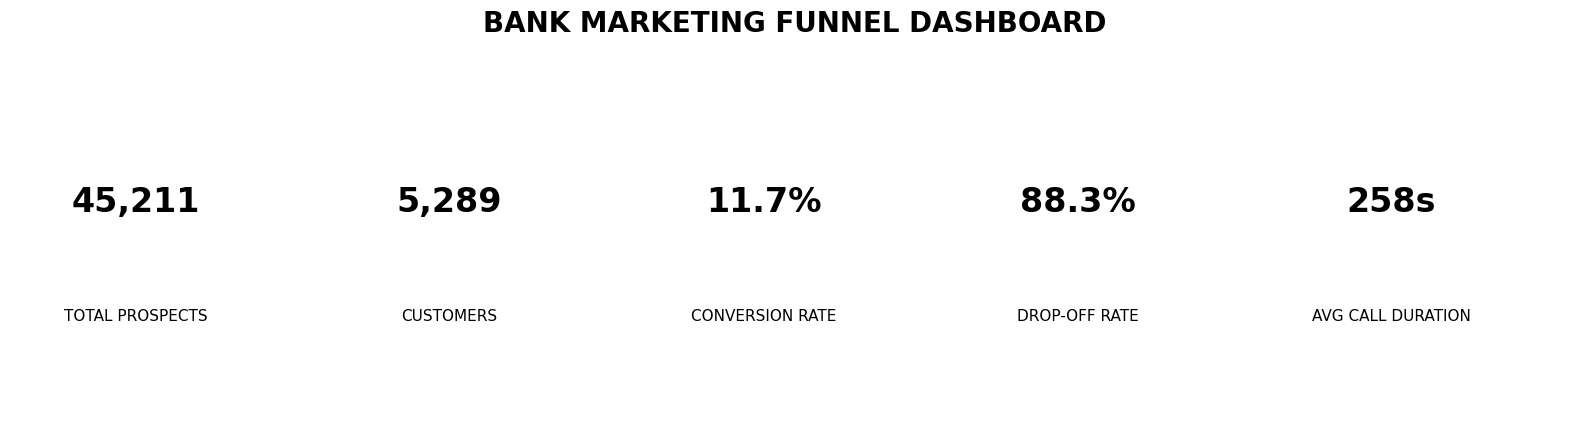

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.axis("off")

kpis = [
    ("TOTAL PROSPECTS", f"{total_prospects:,}"),
    ("CUSTOMERS", f"{total_customers:,}"),
    ("CONVERSION RATE", f"{conversion_rate:.1f}%"),
    ("DROP-OFF RATE", f"{dropoff_rate:.1f}%"),
    ("AVG CALL DURATION", f"{average_duration:.0f}s")
]

positions = [0.08, 0.28, 0.48, 0.68, 0.88]

for (title, value), x in zip(kpis, positions):

    ax.text(
        x, 0.65,
        value,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold"
    )

    ax.text(
        x, 0.30,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

plt.suptitle(
    "BANK MARKETING FUNNEL DASHBOARD",
    fontsize=20,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()

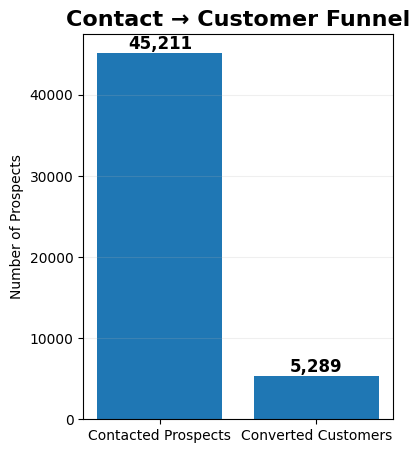

In [ ]:
funnel_stages = [
    "Contacted Prospects",
    "Converted Customers"
]

funnel_values = [
    total_prospects,
    total_customers
]

plt.figure(figsize=(4, 5))

bars = plt.bar(
    funnel_stages,
    funnel_values
)

for bar, value in zip(bars, funnel_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Contact → Customer Funnel",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Prospects")
plt.grid(axis="y", alpha=0.2)

plt.show()

contact_channel
Cellular     14.918900
Telephone    13.420509
Unknown       4.070661
Name: converted, dtype: float64


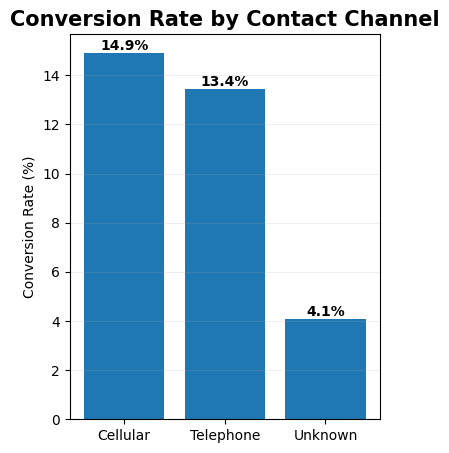

In [ ]:
channel_conversion = (
    df.groupby("contact_channel")["converted"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(channel_conversion)

plt.figure(figsize=(4, 5))

bars = plt.bar(
    channel_conversion.index,
    channel_conversion.values
)

for bar, value in zip(bars, channel_conversion.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Conversion Rate by Contact Channel",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Conversion Rate (%)")
plt.grid(axis="y", alpha=0.2)

plt.show()

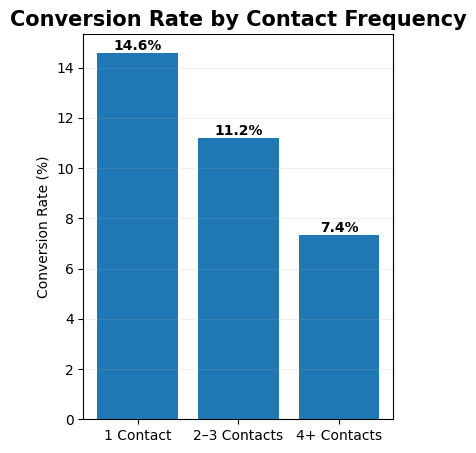

In [ ]:
campaign_order = [
    "1 Contact",
    "2–3 Contacts",
    "4+ Contacts"
]

campaign_conversion = (
    df.groupby("campaign_group")["converted"]
    .mean()
    .reindex(campaign_order)
    * 100
)

plt.figure(figsize=(4, 5))

bars = plt.bar(
    campaign_conversion.index,
    campaign_conversion.values
)

for bar, value in zip(bars, campaign_conversion.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Conversion Rate by Contact Frequency",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Conversion Rate (%)")
plt.grid(axis="y", alpha=0.2)

plt.show()

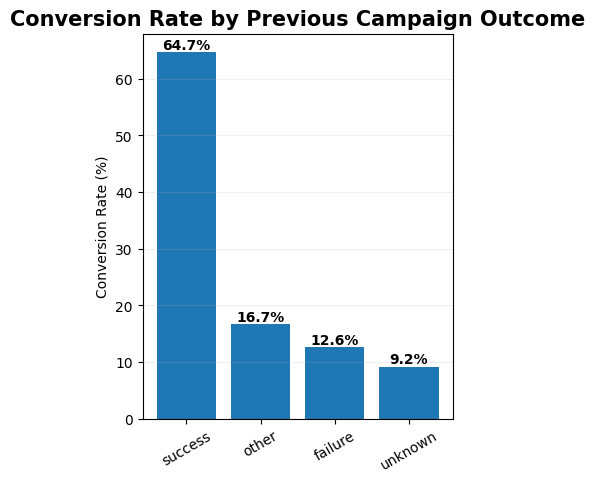

In [ ]:
previous_campaign = (
    df.groupby("poutcome")["converted"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(4, 5))

bars = plt.bar(
    previous_campaign.index,
    previous_campaign.values
)

for bar, value in zip(bars, previous_campaign.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Conversion Rate by Previous Campaign Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.2)

plt.show()

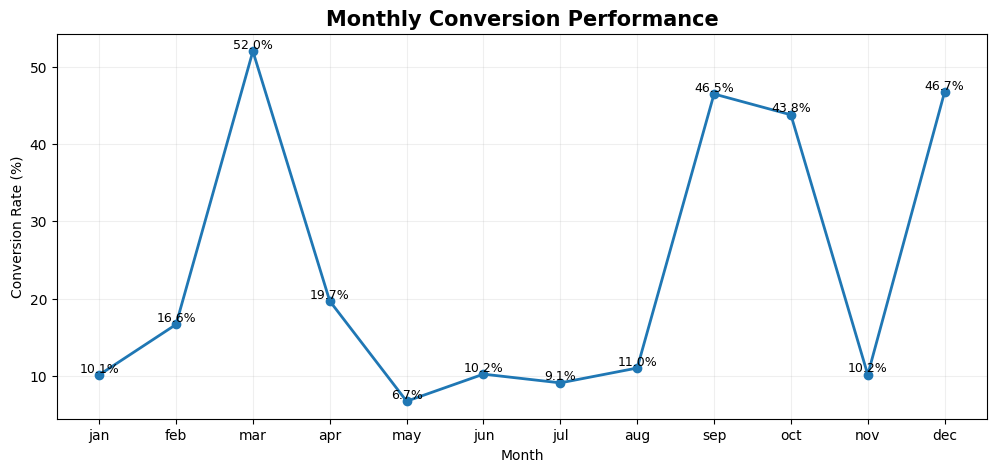

In [ ]:
month_order = [
    "jan", "feb", "mar", "apr",
    "may", "jun", "jul", "aug",
    "sep", "oct", "nov", "dec"
]

monthly_conversion = (
    df.groupby("month")["converted"]
    .mean()
    .reindex(month_order)
    .dropna()
    * 100
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_conversion.index,
    monthly_conversion.values,
    marker="o",
    linewidth=2
)

for x, y in zip(
    monthly_conversion.index,
    monthly_conversion.values
):
    plt.text(
        x, y,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Monthly Conversion Performance",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Conversion Rate (%)")
plt.xlabel("Month")
plt.grid(alpha=0.2)

plt.show()

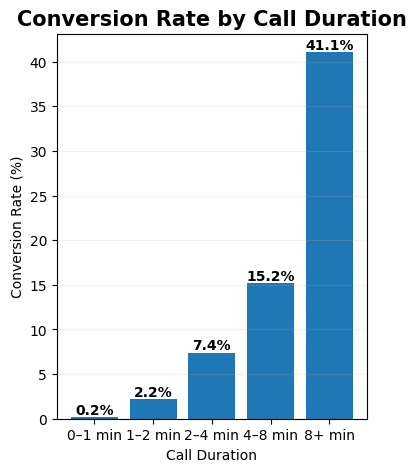

In [ ]:
# Create duration groups
bins = [
    0,
    60,
    120,
    240,
    480,
    np.inf
]

labels = [
    "0–1 min",
    "1–2 min",
    "2–4 min",
    "4–8 min",
    "8+ min"
]

df["duration_group"] = pd.cut(
    df["duration"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

duration_conversion = (
    df.groupby(
        "duration_group",
        observed=True
    )["converted"]
    .mean()
    * 100
)

plt.figure(figsize=(4, 5))

bars = plt.bar(
    duration_conversion.index.astype(str),
    duration_conversion.values
)

for bar, value in zip(
    bars,
    duration_conversion.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Conversion Rate by Call Duration",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Conversion Rate (%)")
plt.xlabel("Call Duration")
plt.grid(axis="y", alpha=0.2)

plt.show()

In [ ]:
dropoff_data = pd.DataFrame({
    "Stage": [
        "Contacted Prospects",
        "Converted Customers",
        "Drop-off"
    ],
    "Count": [
        total_prospects,
        total_customers,
        total_dropoff
    ]
})

dropoff_data["Percentage"] = (
    dropoff_data["Count"] / total_prospects * 100
)

dropoff_data

,Stage,Count,Percentage
0,Contacted Prospects,45211,100.00000
1,Converted Customers,5289,11.69848
2,Drop-off,39922,88.30152


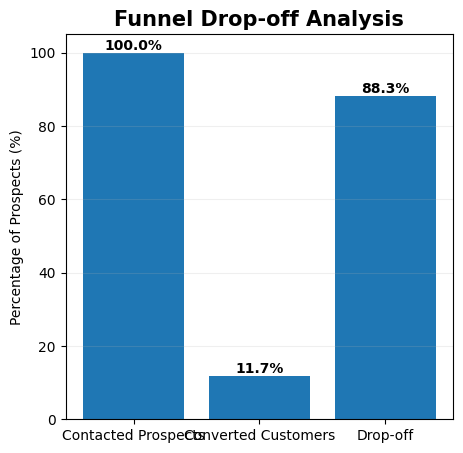

In [ ]:
plt.figure(figsize=(5, 5))

bars = plt.bar(
    dropoff_data["Stage"],
    dropoff_data["Percentage"]
)

for bar, value in zip(
    bars,
    dropoff_data["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Funnel Drop-off Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Percentage of Prospects (%)")
plt.grid(axis="y", alpha=0.2)

plt.show()

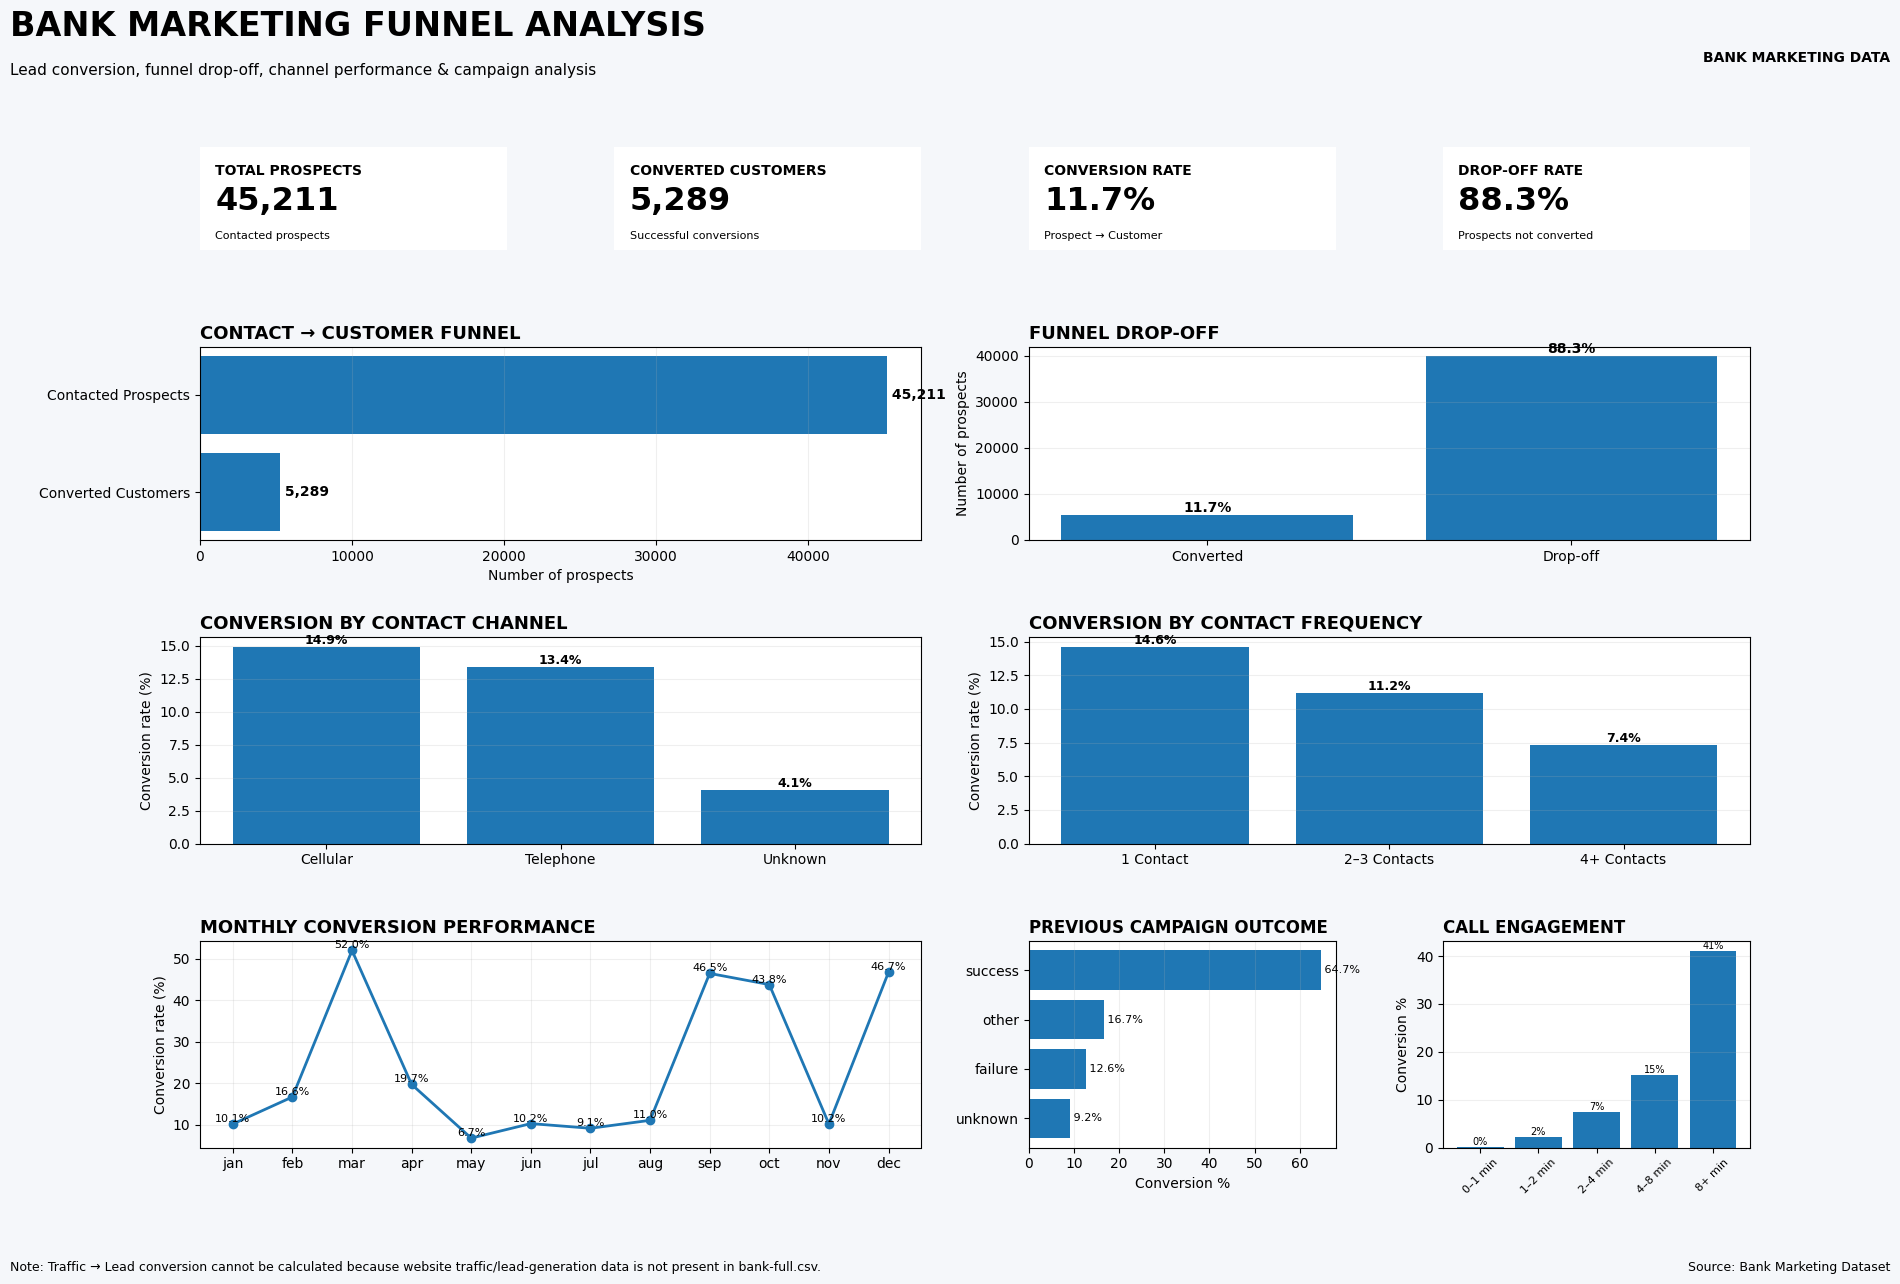

In [ ]:
df.columns = df.columns.str.strip().str.lower()

# Convert target into binary
df["converted"] = np.where(df["y"] == "yes", 1, 0)

# Contact channel labels
df["contact_channel"] = df["contact"].replace({
    "cellular": "Cellular",
    "telephone": "Telephone",
    "unknown": "Unknown"
})

# Campaign/contact frequency
df["campaign_group"] = np.select(
    [
        df["campaign"] == 1,
        df["campaign"].between(2, 3),
        df["campaign"] >= 4
    ],
    [
        "1 Contact",
        "2–3 Contacts",
        "4+ Contacts"
    ],
    default="Unknown"
)

# Duration groups
duration_bins = [0, 60, 120, 240, 480, np.inf]

duration_labels = [
    "0–1 min",
    "1–2 min",
    "2–4 min",
    "4–8 min",
    "8+ min"
]

df["duration_group"] = pd.cut(
    df["duration"],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

# -----------------------------
# 3. KPI CALCULATIONS
# -----------------------------

total_prospects = len(df)

converted_customers = df["converted"].sum()

dropoff_customers = total_prospects - converted_customers

conversion_rate = (
    converted_customers / total_prospects
) * 100

dropoff_rate = (
    dropoff_customers / total_prospects
) * 100

avg_call_duration = df["duration"].mean()

avg_campaign_contacts = df["campaign"].mean()

# -----------------------------
# 4. SEGMENT ANALYSIS
# -----------------------------

# Channel conversion
channel_conversion = (
    df.groupby("contact_channel")["converted"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Campaign conversion
campaign_order = [
    "1 Contact",
    "2–3 Contacts",
    "4+ Contacts"
]

campaign_conversion = (
    df.groupby("campaign_group")["converted"]
    .mean()
    .mul(100)
    .reindex(campaign_order)
)

# Previous campaign outcome
previous_conversion = (
    df.groupby("poutcome")["converted"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Monthly conversion
month_order = [
    "jan", "feb", "mar", "apr",
    "may", "jun", "jul", "aug",
    "sep", "oct", "nov", "dec"
]

monthly_conversion = (
    df.groupby("month")["converted"]
    .mean()
    .mul(100)
    .reindex(month_order)
)

# Duration conversion
duration_conversion = (
    df.groupby("duration_group", observed=True)["converted"]
    .mean()
    .mul(100)
)
plt.close("all")

fig = plt.figure(
    figsize=(20, 13),
    facecolor="#F5F7FA"
)

# Dashboard layout
gs = fig.add_gridspec(
    4,
    4,
    height_ratios=[0.75, 1.4, 1.5, 1.5],
    hspace=0.55,
    wspace=0.35
)

# ============================================================
# TITLE
# ============================================================

fig.text(
    0.03,
    0.965,
    "BANK MARKETING FUNNEL ANALYSIS",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.03,
    0.935,
    "Lead conversion, funnel drop-off, channel performance & campaign analysis",
    fontsize=11
)

fig.text(
    0.97,
    0.945,
    "BANK MARKETING DATA",
    ha="right",
    fontsize=10,
    fontweight="bold"
)

# ============================================================
# KPI CARD FUNCTION
# ============================================================

def create_kpi(ax, title, value, subtitle=""):

    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.05,
        0.72,
        title,
        fontsize=10,
        fontweight="bold",
        transform=ax.transAxes
    )

    ax.text(
        0.05,
        0.38,
        value,
        fontsize=23,
        fontweight="bold",
        transform=ax.transAxes
    )

    if subtitle:
        ax.text(
            0.05,
            0.10,
            subtitle,
            fontsize=8,
            transform=ax.transAxes
        )


# ============================================================
# KPI CARDS
# ============================================================

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])

create_kpi(
    ax1,
    "TOTAL PROSPECTS",
    f"{total_prospects:,}",
    "Contacted prospects"
)

create_kpi(
    ax2,
    "CONVERTED CUSTOMERS",
    f"{converted_customers:,}",
    "Successful conversions"
)

create_kpi(
    ax3,
    "CONVERSION RATE",
    f"{conversion_rate:.1f}%",
    "Prospect → Customer"
)

create_kpi(
    ax4,
    "DROP-OFF RATE",
    f"{dropoff_rate:.1f}%",
    "Prospects not converted"
)

# ============================================================
# FUNNEL CHART
# ============================================================

ax5 = fig.add_subplot(gs[1, 0:2])

funnel_labels = [
    "Contacted Prospects",
    "Converted Customers"
]

funnel_values = [
    total_prospects,
    converted_customers
]

bars = ax5.barh(
    funnel_labels,
    funnel_values
)

ax5.invert_yaxis()

for bar, value in zip(bars, funnel_values):

    ax5.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f" {value:,}",
        va="center",
        fontweight="bold"
    )

ax5.set_title(
    "CONTACT → CUSTOMER FUNNEL",
    loc="left",
    fontsize=13,
    fontweight="bold"
)

ax5.set_xlabel("Number of prospects")

ax5.grid(
    axis="x",
    alpha=0.2
)

# ============================================================
# DROP-OFF CHART
# ============================================================

ax6 = fig.add_subplot(gs[1, 2:4])

dropoff_labels = [
    "Converted",
    "Drop-off"
]

dropoff_values = [
    converted_customers,
    dropoff_customers
]

bars = ax6.bar(
    dropoff_labels,
    dropoff_values
)

for bar, value in zip(
    bars,
    dropoff_values
):

    percentage = value / total_prospects * 100

    ax6.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax6.set_title(
    "FUNNEL DROP-OFF",
    loc="left",
    fontsize=13,
    fontweight="bold"
)

ax6.set_ylabel("Number of prospects")

ax6.grid(
    axis="y",
    alpha=0.2
)

# ============================================================
# CHANNEL PERFORMANCE
# ============================================================

ax7 = fig.add_subplot(gs[2, 0:2])

bars = ax7.bar(
    channel_conversion.index,
    channel_conversion.values
)

for bar, value in zip(
    bars,
    channel_conversion.values
):

    ax7.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax7.set_title(
    "CONVERSION BY CONTACT CHANNEL",
    loc="left",
    fontsize=13,
    fontweight="bold"
)

ax7.set_ylabel("Conversion rate (%)")

ax7.grid(
    axis="y",
    alpha=0.2
)

# ============================================================
# CAMPAIGN FREQUENCY
# ============================================================

ax8 = fig.add_subplot(gs[2, 2:4])

bars = ax8.bar(
    campaign_conversion.index,
    campaign_conversion.values
)

for bar, value in zip(
    bars,
    campaign_conversion.values
):

    ax8.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax8.set_title(
    "CONVERSION BY CONTACT FREQUENCY",
    loc="left",
    fontsize=13,
    fontweight="bold"
)

ax8.set_ylabel("Conversion rate (%)")

ax8.grid(
    axis="y",
    alpha=0.2
)

# ============================================================
# MONTHLY PERFORMANCE
# ============================================================

ax9 = fig.add_subplot(gs[3, 0:2])

ax9.plot(
    monthly_conversion.index,
    monthly_conversion.values,
    marker="o",
    linewidth=2
)

for month, value in monthly_conversion.items():

    if pd.notna(value):

        ax9.text(
            month,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax9.set_title(
    "MONTHLY CONVERSION PERFORMANCE",
    loc="left",
    fontsize=13,
    fontweight="bold"
)

ax9.set_ylabel("Conversion rate (%)")

ax9.grid(alpha=0.2)

# ============================================================
# PREVIOUS CAMPAIGN PERFORMANCE
# ============================================================

ax10 = fig.add_subplot(gs[3, 2])

previous_display = previous_conversion.head(5)

bars = ax10.barh(
    previous_display.index,
    previous_display.values
)

ax10.invert_yaxis()

for bar, value in zip(
    bars,
    previous_display.values
):

    ax10.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f" {value:.1f}%",
        va="center",
        fontsize=8
    )

ax10.set_title(
    "PREVIOUS CAMPAIGN OUTCOME",
    loc="left",
    fontsize=12,
    fontweight="bold"
)

ax10.set_xlabel("Conversion %")

ax10.grid(
    axis="x",
    alpha=0.2
)

# ============================================================
# CALL DURATION
# ============================================================

ax11 = fig.add_subplot(gs[3, 3])

bars = ax11.bar(
    duration_conversion.index.astype(str),
    duration_conversion.values
)

for bar, value in zip(
    bars,
    duration_conversion.values
):

    ax11.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.0f}%",
        ha="center",
        va="bottom",
        fontsize=7
    )

ax11.set_title(
    "CALL ENGAGEMENT",
    loc="left",
    fontsize=12,
    fontweight="bold"
)

ax11.set_ylabel("Conversion %")

ax11.tick_params(
    axis="x",
    rotation=45,
    labelsize=8
)

ax11.grid(
    axis="y",
    alpha=0.2
)

# ============================================================
# DASHBOARD FOOTER
# ============================================================

fig.text(
    0.03,
    0.015,
    "Note: Traffic → Lead conversion cannot be calculated because website traffic/lead-generation data is not present in bank-full.csv.",
    fontsize=9
)

fig.text(
    0.97,
    0.015,
    "Source: Bank Marketing Dataset",
    ha="right",
    fontsize=9
)

plt.show()